# Repressilator Series Interpolation

This notebook runs OT-CFM, SB-CFM and SF2M on the repressilator (classic) data.

In [10]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

savedir = "models"
os.makedirs(savedir, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
data = np.load(f"../../../Supercloud/realdata/data/processed_pbmc_data_sub500_every_2_until20.npz")
data_val = np.load(f"../../../Supercloud/realdata/data/processed_pbmc_data_sub500_every_2_until20_interp_val.npz")

In [12]:
dts

tensor([0.0000, 0.0500, 0.1000, 0.1500, 0.2000, 0.2500, 0.3000, 0.3500, 0.4000,
        0.4500, 0.5000, 0.5500, 0.6000, 0.6500, 0.7000, 0.7500, 0.8000, 0.8500,
        0.9000, 0.9500, 1.0000], dtype=torch.float64)

In [13]:
dts = torch.tensor(data['dts'])
t_start = dts[0]
t_end = dts[-2]
X0 = torch.tensor(data["Xs"][0])
time_scale = data['time_scale']

In [14]:
n_times = len(dts)
X = [data['Xs'][t] for t in range(n_times)]

In [15]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
sigma = 0.1
dim = 30
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

In [16]:
def get_batch(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with point sfrom each timepoint pair"""
    ts = []
    xts = []
    uts = []
    noises = []
    for t_start in range(n_times - 1):
        x0 = (
            torch.from_numpy(X[t_start][np.random.randint(X[t_start].shape[0], size=batch_size)])
            .float()
            .to(device)
        )
        x1 = (
            torch.from_numpy(
                X[t_start + 1][np.random.randint(X[t_start + 1].shape[0], size=batch_size)]
            )
            .float()
            .to(device)
        )
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, return_noise=return_noise)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut

## OT-CFM

In [17]:
for i in tqdm(range(10000)):
    ot_cfm_optimizer.zero_grad()
    t, xt, ut = get_batch(FM, X, batch_size, n_times)
    vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)
    loss.backward()
    ot_cfm_optimizer.step()

100%|██████████| 10000/10000 [11:57<00:00, 13.94it/s]


In [18]:
node_ot_cfm = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj_ot_cfm = node_ot_cfm.trajectory(
        torch.from_numpy(X[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()

/var/folders/4_/h0m8n1bs7xx5d9_v5dj1dgvm0000gn/T/ipykernel_18756/3433807262.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_slices = cm.get_cmap("coolwarm")


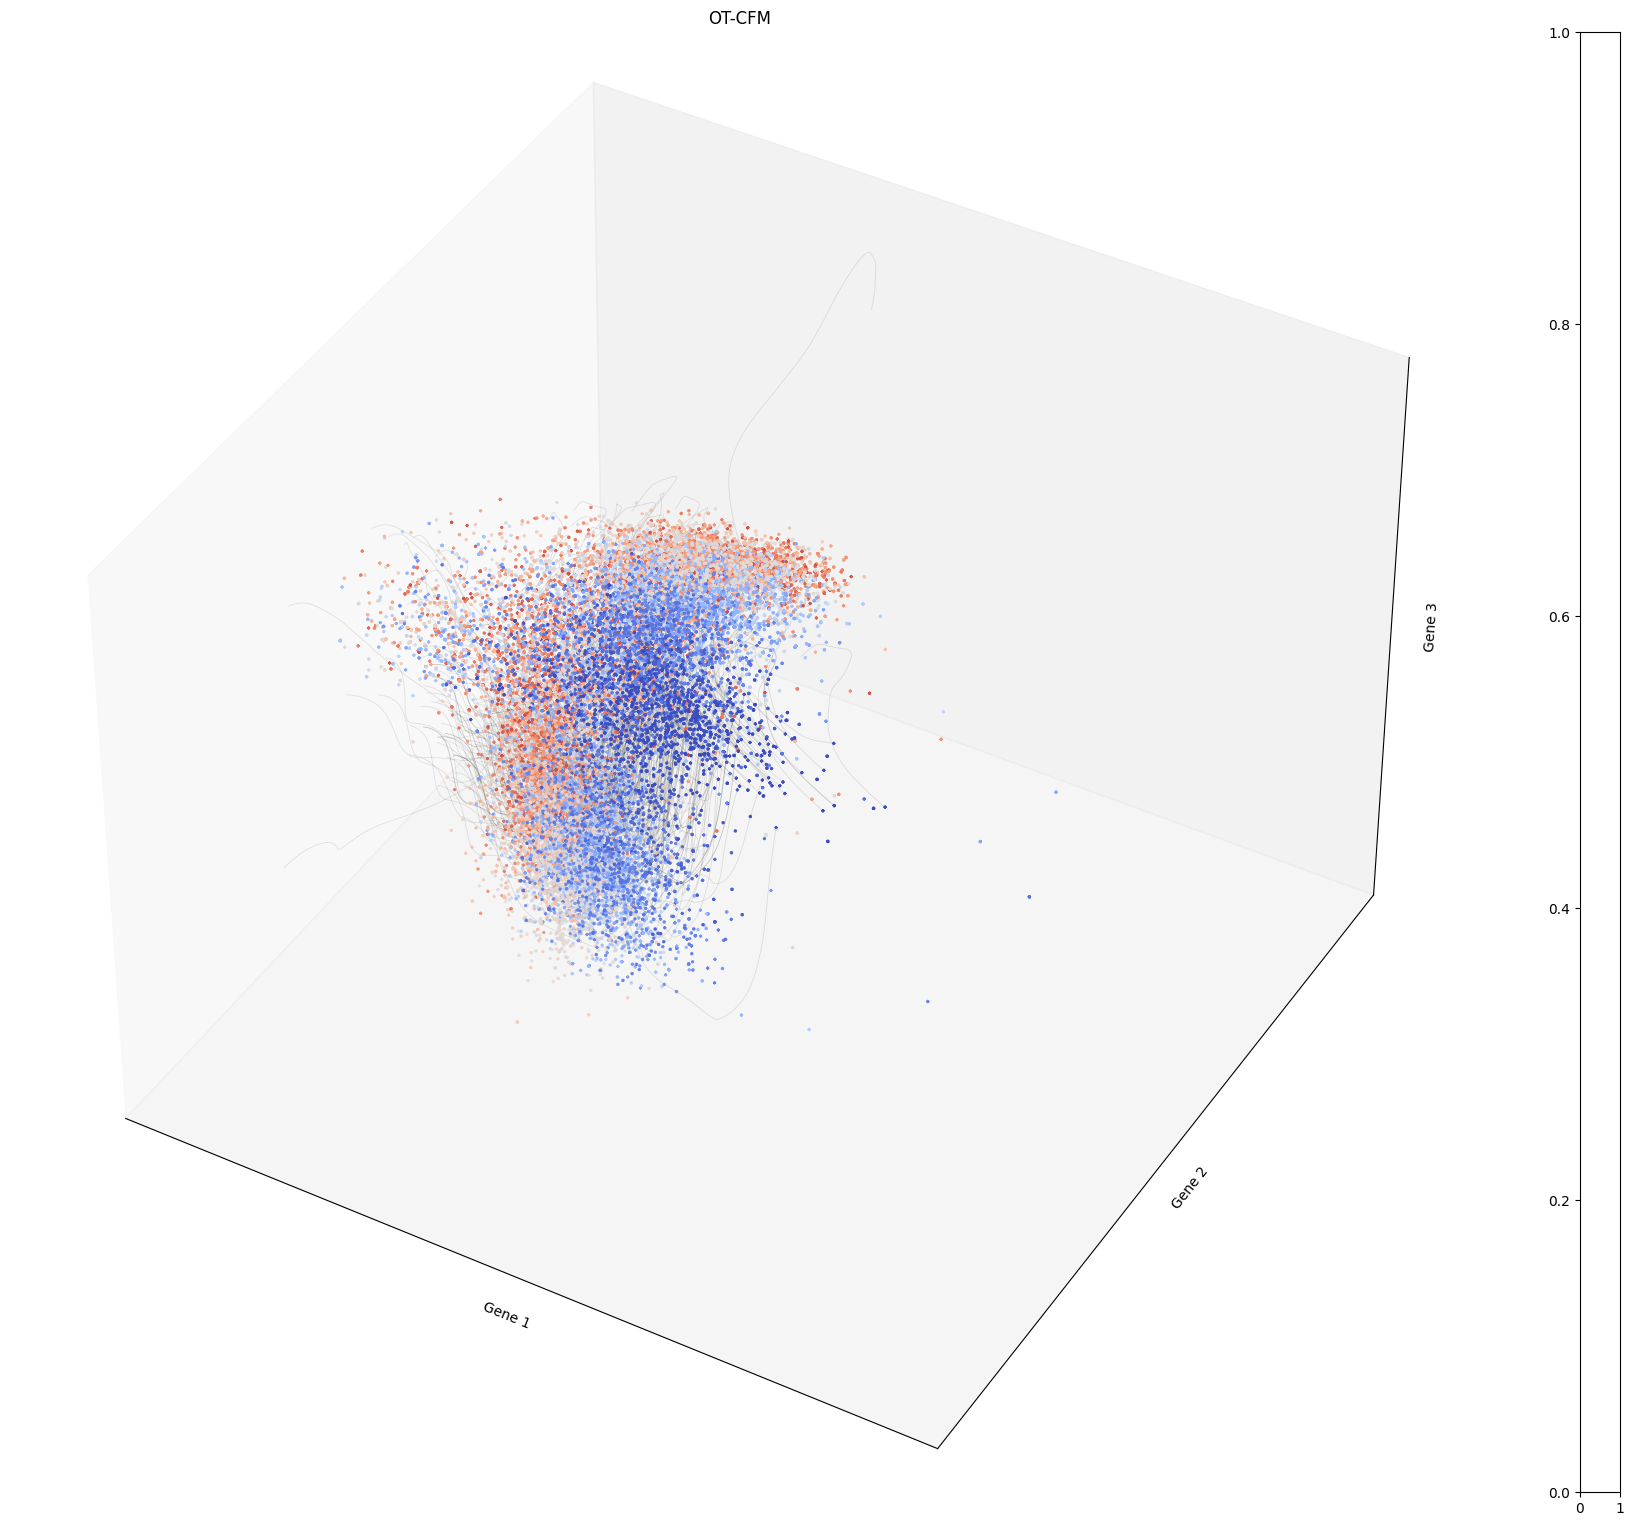

In [19]:
from matplotlib import cm

fig = plt.figure(figsize=(20, 20))
fig.subplots_adjust(left=0.06, right=0.86, bottom=0.15, top=0.88, wspace=0.2)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.73])  # colorbar for training slices
axs = [fig.add_subplot(1, 1, 1, projection='3d')]
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_zticks([])
axs[0].set_xlabel("Gene 1", labelpad=-3)
axs[0].set_ylabel("Gene 2", labelpad=-3)
axs[0].set_zlabel("Gene 3", labelpad=-3)
axs[0].view_init(-140, 60)
cmap_slices = cm.get_cmap("coolwarm")
n_slices = len(X)

for i, plot_data in enumerate(data['Xs']):
    color_i = cmap_slices(i / (n_slices + 1))
    for j in range(3):
        axs[0].scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], color=color_i, marker="x", s=2)

for i, plot_data in enumerate(data_val['Xs']):
    color_i = cmap_slices(i / (n_slices + 1))
    for j in range(3):
        axs[0].scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], color=color_i, marker="o", s=2)

# Visualize the trajectories
plt.title("OT-CFM")
for i in range(traj_ot_cfm.shape[1]):
    axs[0].plot(traj_ot_cfm[:, i, 0], traj_ot_cfm[:, i, 1], traj_ot_cfm[:, i, 2], color="black", alpha = 0.1, lw=.6)

In [20]:
torch.save(
    {
        "model": ot_cfm_model,
        "optimizer": ot_cfm_optimizer,
    },
    f"{savedir}/ot_cfm_pbmc.pt",
)

## SF2M



In [21]:
sigma = 0.25
sf2m_model = MLP(dim=dim, time_varying=True, w=64).to(device)
sf2m_score_model = MLP(dim=dim, time_varying=True, w=64).to(device)
sf2m_optimizer = torch.optim.AdamW(
    list(sf2m_model.parameters()) + list(sf2m_score_model.parameters()), 1e-4
)
SF2M = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)

In [22]:
max_norm_ut = torch.tensor(0.0)
for i in tqdm(range(10000)):
    sf2m_optimizer.zero_grad()
    t, xt, ut, eps = get_batch(SF2M, X, batch_size, n_times, return_noise=True)
    lambda_t = SF2M.compute_lambda(t % 1)
    vt = sf2m_model(torch.cat([xt, t[:, None]], dim=-1))
    st = sf2m_score_model(torch.cat([xt, t[:, None]], dim=-1))
    flow_loss = torch.mean((vt - ut) ** 2)
    # max_norm_ut = torch.maximum(torch.max(torch.sum(ut**2, dim=1)), max_norm_ut)
    score_loss = torch.mean((lambda_t[:, None] * st + eps) ** 2)
    if i % 1000 == 0:
        # print(max_norm_ut)
        print(f"{i}: {flow_loss.item():0.2f}, {score_loss.item():0.2f}")
    loss = flow_loss + score_loss

    loss.backward()
    sf2m_optimizer.step()

  0%|          | 2/10000 [00:00<12:35, 13.23it/s]

0: 1.14, 2.90


 10%|█         | 1002/10000 [01:16<10:57, 13.69it/s]

1000: 0.21, 0.85


 20%|██        | 2002/10000 [02:28<09:42, 13.73it/s]

...

 80%|████████  | 8002/10000 [09:54<02:30, 13.30it/s]

8000: 0.35, 0.48


 90%|█████████ | 9002/10000 [11:10<01:14, 13.32it/s]

9000: 1.11, 0.48


100%|██████████| 10000/10000 [12:25<00:00, 13.41it/s]


In [23]:
nod_sb_cfm = NeuralODE(torch_wrapper(sf2m_model), solver="euler", sensitivity="adjoint")
x0 = torch.from_numpy(X[0][:1000]).float()
with torch.no_grad():
    traj_sb_cfm = nod_sb_cfm.trajectory(
        x0.to(device),
        t_span=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

/var/folders/4_/h0m8n1bs7xx5d9_v5dj1dgvm0000gn/T/ipykernel_18756/3467012800.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_slices = cm.get_cmap("coolwarm")


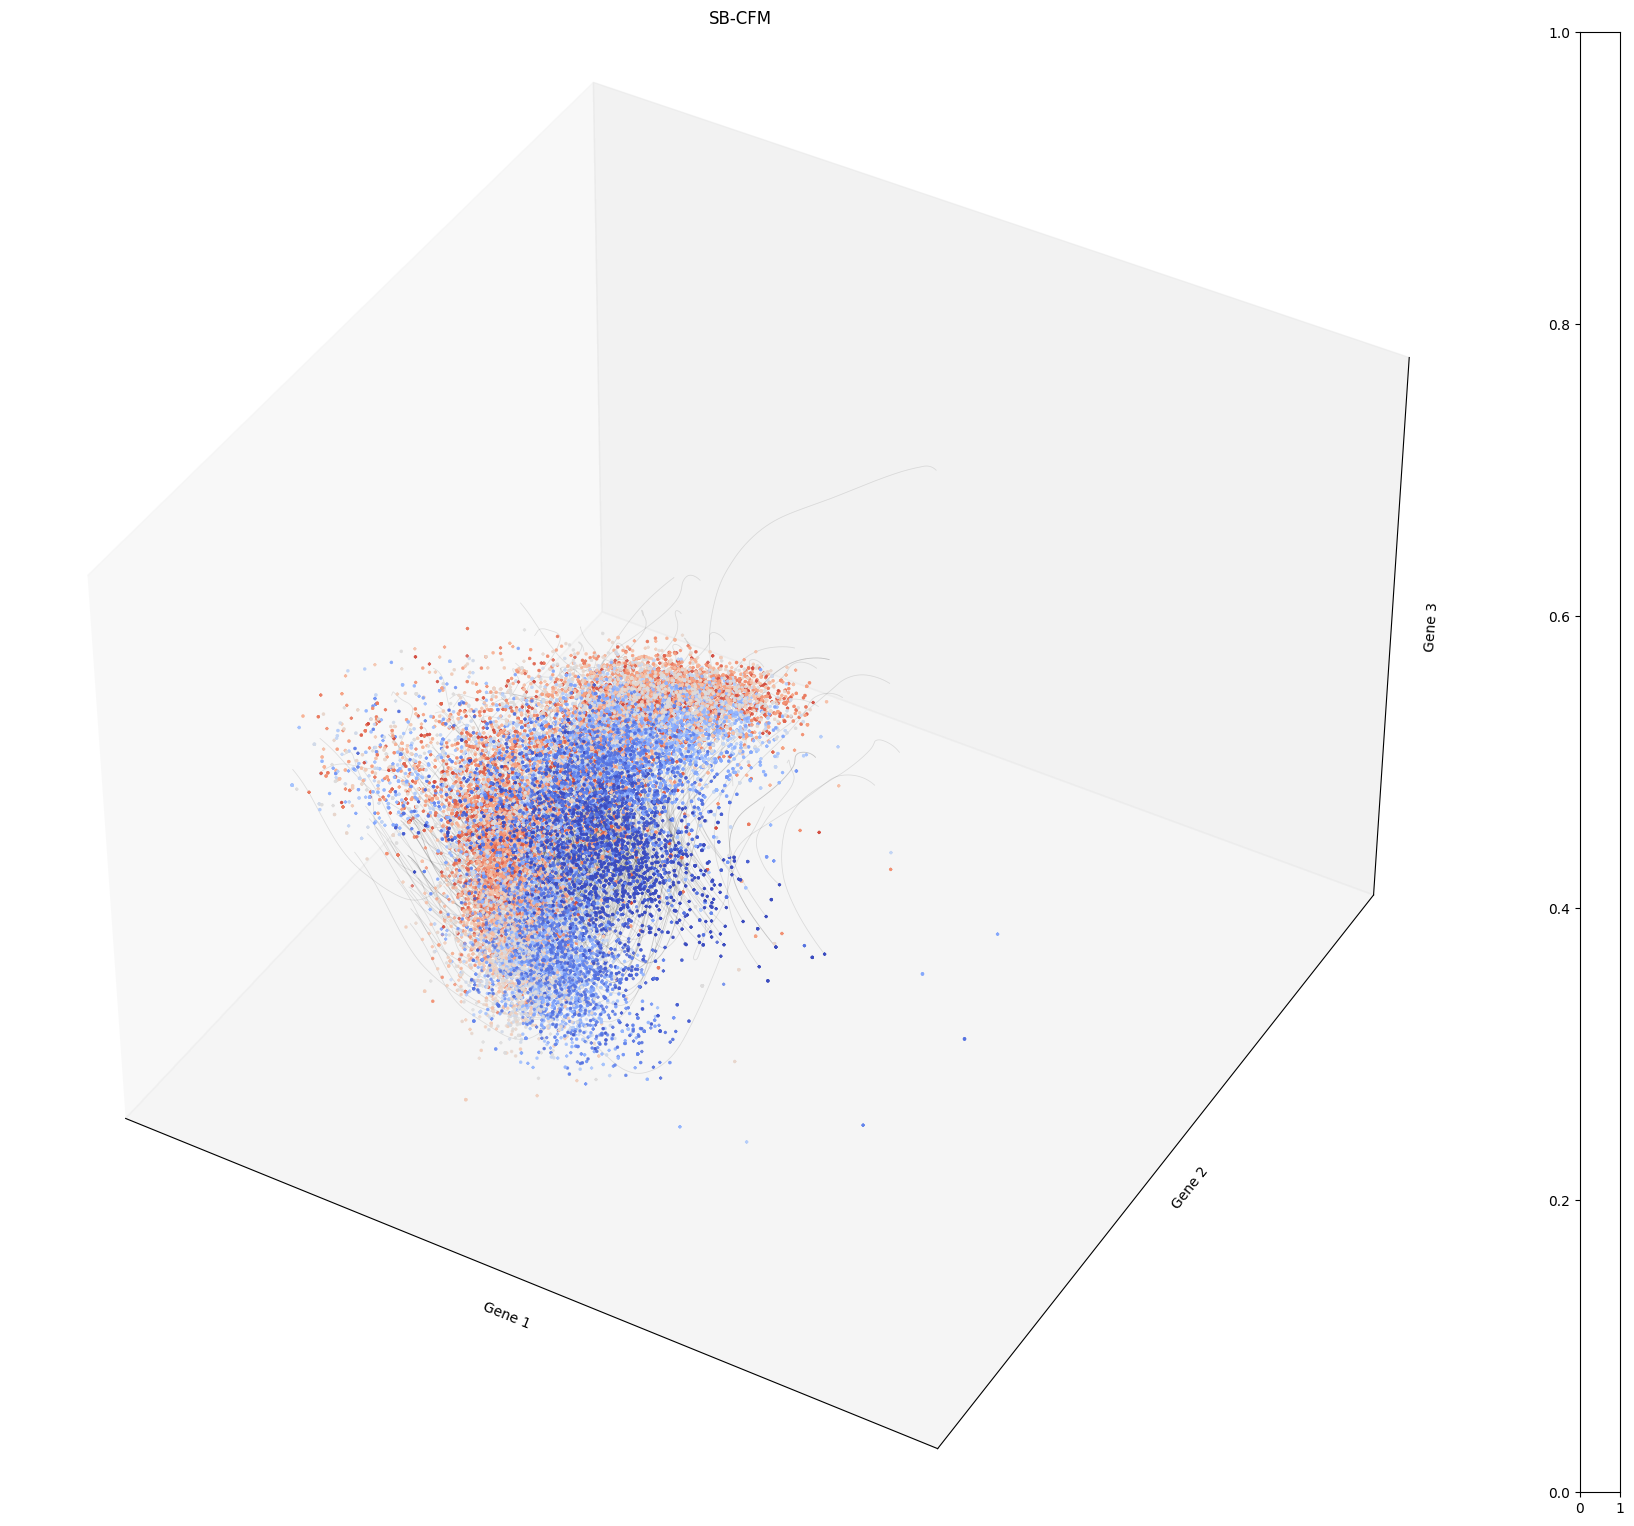

In [24]:
from matplotlib import cm

fig = plt.figure(figsize=(20, 20))
fig.subplots_adjust(left=0.06, right=0.86, bottom=0.15, top=0.88, wspace=0.2)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.73])  # colorbar for training slices
axs = [fig.add_subplot(1, 1, 1, projection='3d')]
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_zticks([])
axs[0].set_xlabel("Gene 1", labelpad=-3)
axs[0].set_ylabel("Gene 2", labelpad=-3)
axs[0].set_zlabel("Gene 3", labelpad=-3)
axs[0].view_init(-140, 60)
cmap_slices = cm.get_cmap("coolwarm")
n_slices = len(X)

for i, plot_data in enumerate(data['Xs']):
    color_i = cmap_slices(i / (n_slices + 1))
    for j in range(3):
        axs[0].scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], color=color_i, marker="x", s=2)

for i, plot_data in enumerate(data_val['Xs']):
    color_i = cmap_slices(i / (n_slices + 1))
    for j in range(3):
        axs[0].scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], color=color_i, marker="o", s=2)

# Visualize the trajectories
plt.title("SB-CFM")
for i in range(traj_sb_cfm.shape[1]):
    axs[0].plot(traj_sb_cfm[:, i, 0], traj_sb_cfm[:, i, 1], traj_sb_cfm[:, i, 2], color="black", alpha = 0.1, lw=.6)

In [25]:
class SDE(torch.nn.Module):
    noise_type = "diagonal"
    sde_type = "ito"

    def __init__(self, ode_drift, score, input_size=(3, 32, 32), sigma=1.0):
        super().__init__()
        self.drift = ode_drift
        self.score = score
        self.input_size = input_size
        self.sigma = sigma

    # Drift
    def f(self, t, y):
        y = y.view(-1, *self.input_size)
        if len(t.shape) == len(y.shape):
            x = torch.cat([y, t], 1)
        else:
            x = torch.cat([y, t.repeat(y.shape[0])[:, None]], 1)
        return self.drift(x).flatten(start_dim=1) + self.score(x).flatten(start_dim=1)

    # Diffusion
    def g(self, t, y):
        return torch.ones_like(y) * self.sigma


sde = SDE(sf2m_model, sf2m_score_model, input_size=(30,), sigma=sigma)
with torch.no_grad():
    sde_traj = torchsde.sdeint(
        sde,
        x0.to(device),
        ts=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

/var/folders/4_/h0m8n1bs7xx5d9_v5dj1dgvm0000gn/T/ipykernel_18756/614561439.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_slices = cm.get_cmap("coolwarm")


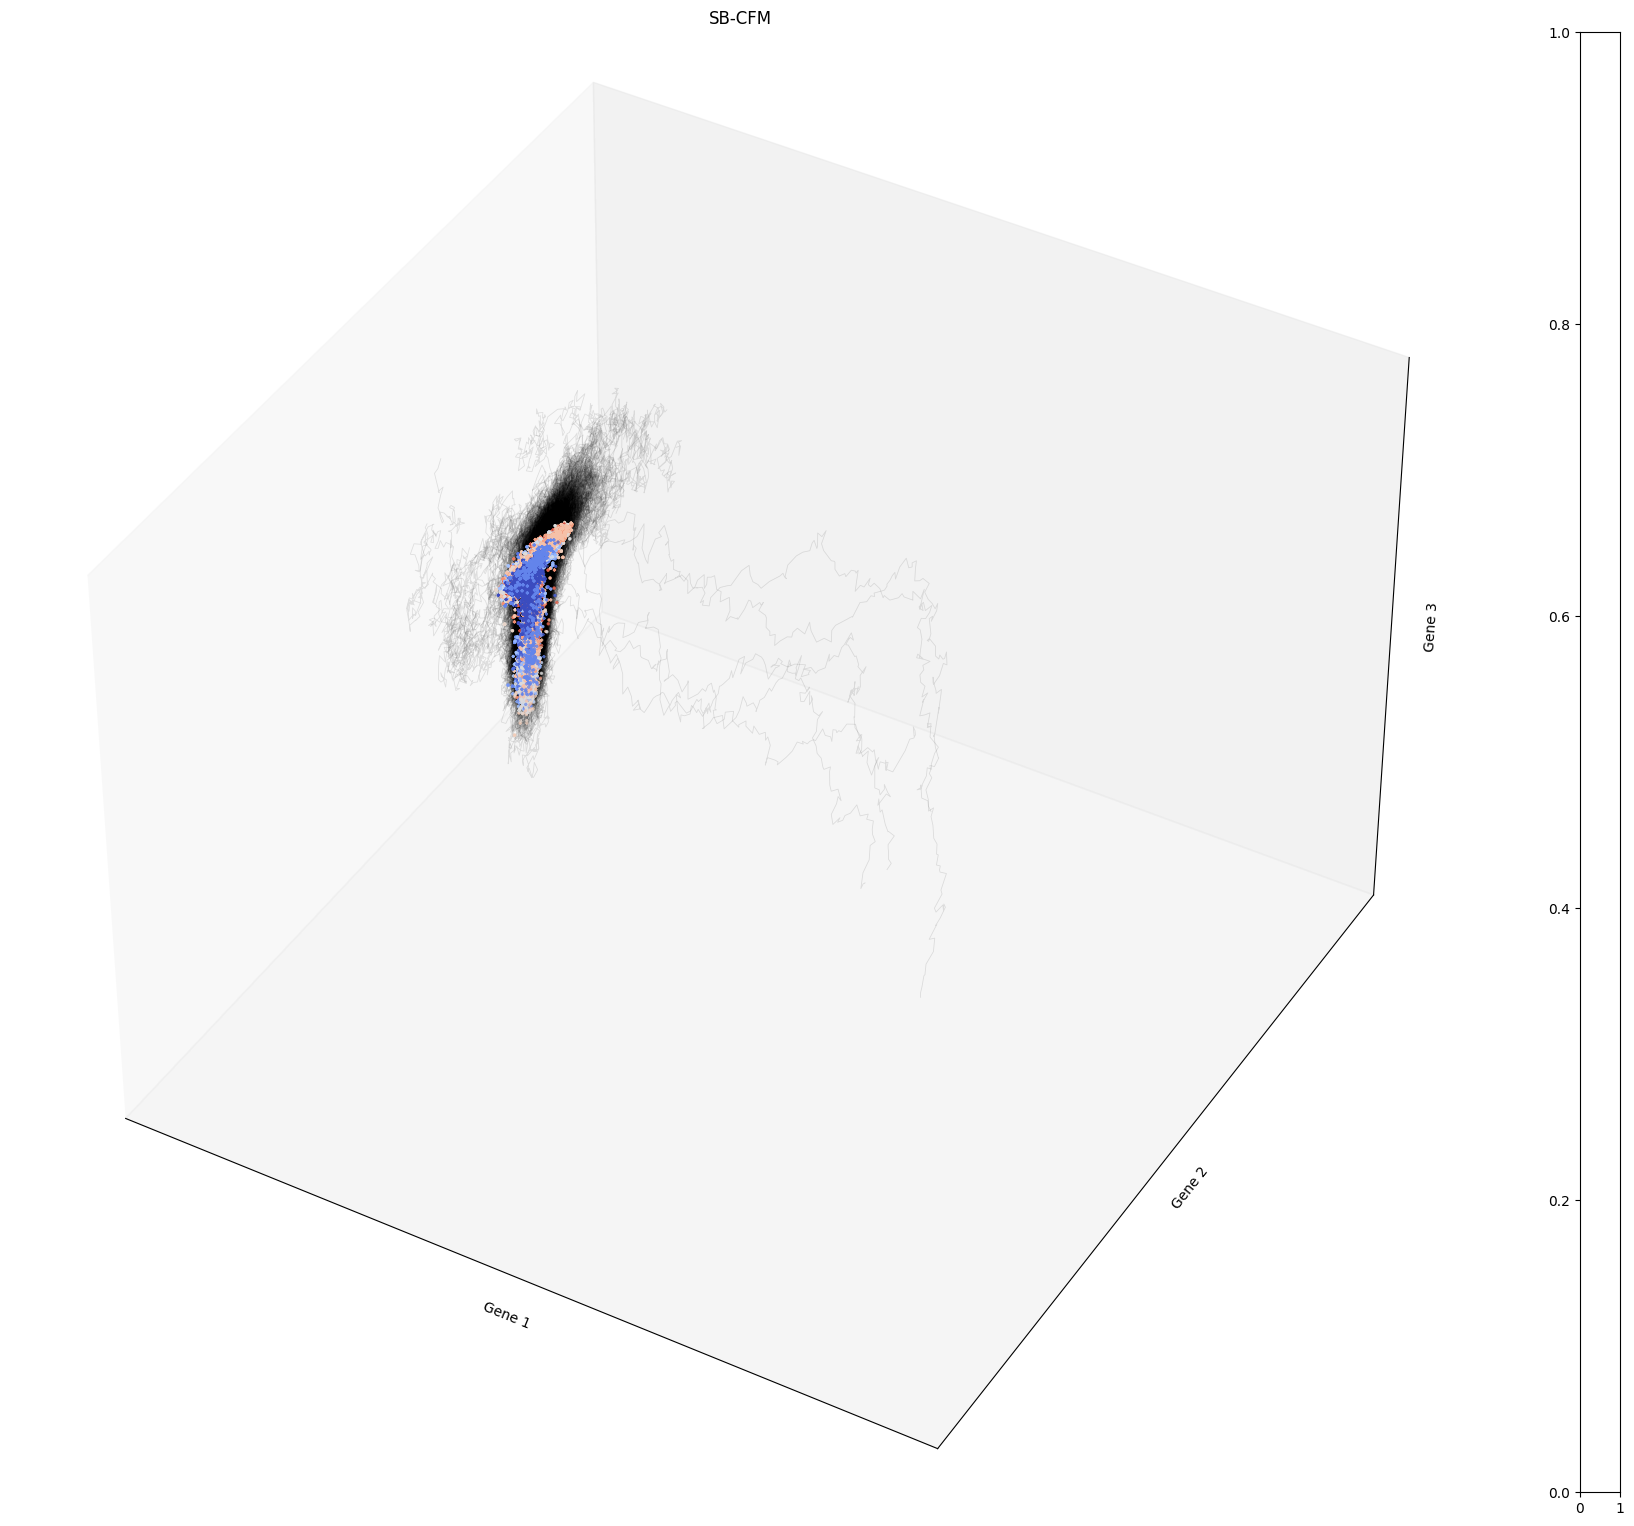

In [26]:
from matplotlib import cm

fig = plt.figure(figsize=(20, 20))
fig.subplots_adjust(left=0.06, right=0.86, bottom=0.15, top=0.88, wspace=0.2)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.73])  # colorbar for training slices
axs = [fig.add_subplot(1, 1, 1, projection='3d')]
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_zticks([])
axs[0].set_xlabel("Gene 1", labelpad=-3)
axs[0].set_ylabel("Gene 2", labelpad=-3)
axs[0].set_zlabel("Gene 3", labelpad=-3)
axs[0].view_init(-140, 60)
cmap_slices = cm.get_cmap("coolwarm")
n_slices = len(X)

for i, plot_data in enumerate(data['Xs']):
    color_i = cmap_slices(i / (n_slices + 1))
    for j in range(3):
        axs[0].scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], color=color_i, marker="x", s=2)

for i, plot_data in enumerate(data_val['Xs']):
    color_i = cmap_slices(i / (n_slices + 1))
    for j in range(3):
        axs[0].scatter(plot_data[:, 0], plot_data[:, 1], plot_data[:, 2], color=color_i, marker="o", s=2)

# Visualize the trajectories
plt.title("SB-CFM")
for i in range(sde_traj.shape[1]):
    axs[0].plot(sde_traj[:, i, 0], sde_traj[:, i, 1], sde_traj[:, i, 2], color="black", alpha = 0.1, lw=.6)

In [27]:
torch.save(
    {
        "model": sf2m_model,
        "score_model": sf2m_score_model,
        "optimizer": sf2m_optimizer,
    },
    f"{savedir}/sf2m_pbmc_sigma_{sigma}.pt",
)